In [3]:
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [4]:
# 1. Load the single-cell engineered dataset
print("Loading single-cell engineered features...")
df = pd.read_csv('./data/engineered_features.csv', index_col='Timestamp', parse_dates=True)

Loading single-cell engineered features...


In [5]:
# 2. Upgrade the Target: Predict 1 Hour Ahead (4 steps)
# We shift the target volume backwards by 4 rows. 
# This trains the model to look at current conditions and guess the traffic 60 minutes from now.
df['target_1h_ahead'] = df['4G data volume DL'].shift(-4)

# Drop the final 4 rows which now lack a future target
df = df.dropna()

In [6]:
# 3. Define Features (X) and Target (y)
features = [
    '4G data volume DL', '4G RB utilization', 
    'hour', 'minute', 'day_of_week', 'is_weekend', 
    'vol_lag_1', 'vol_lag_4', 'vol_lag_96'
]
X = df[features]
y = df['target_1h_ahead']

In [7]:
# 4. Chronological Train/Test Split
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training on {len(X_train)} intervals, Testing on {len(X_test)} intervals.")

Training on 6561 intervals, Testing on 1641 intervals.


In [8]:
# 5. Train the 1-Hour Ahead XGBoost Model
print("Training XGBoost Regressor for 1-Hour Forecasting...")
model_1h = xgb.XGBRegressor(
    n_estimators=200, 
    learning_rate=0.05, 
    max_depth=5, 
    random_state=42,
    objective='reg:squarederror'
)
model_1h.fit(X_train, y_train)

Training XGBoost Regressor for 1-Hour Forecasting...


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [9]:
# 6. Predict and Evaluate
y_pred = model_1h.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n--- 1-Hour Ahead Model Performance ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} GB")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} GB")


--- 1-Hour Ahead Model Performance ---
Mean Absolute Error (MAE): 404.79 GB
Root Mean Squared Error (RMSE): 539.71 GB


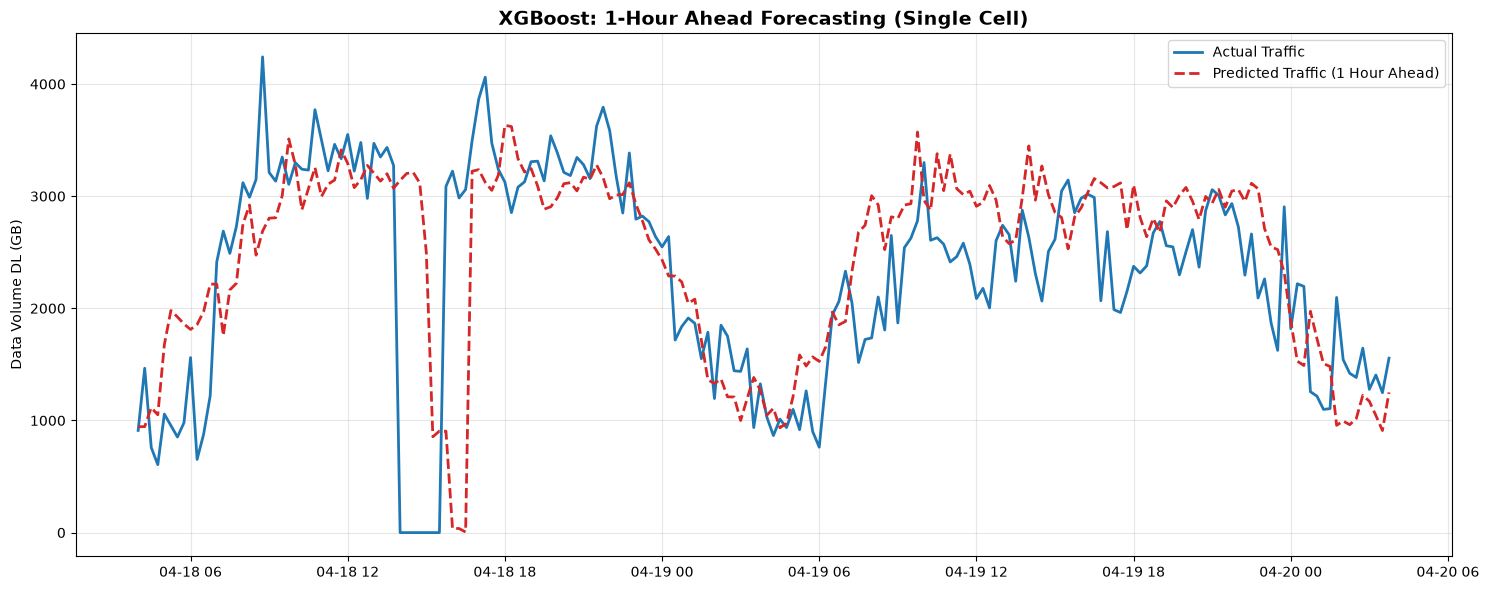

<Figure size 1000x400 with 0 Axes>

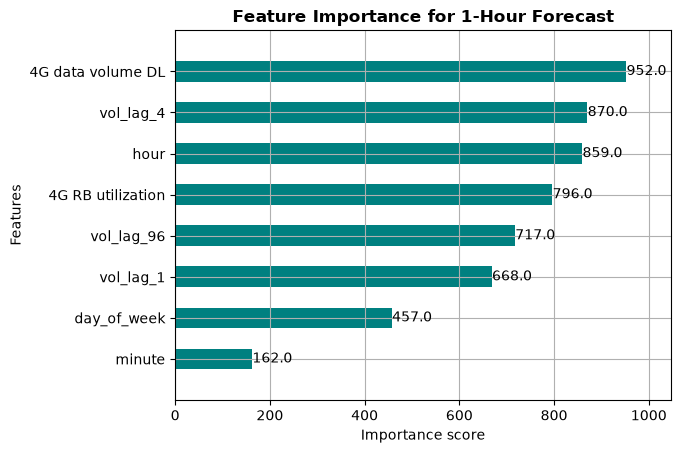

In [10]:
# 7. Plot Actual vs Predicted (2-day test subset)
subset_size = 192
plt.figure(figsize=(15, 6))
plt.plot(y_test.index[:subset_size], y_test.iloc[:subset_size], label='Actual Traffic', color='tab:blue', linewidth=2)
plt.plot(y_test.index[:subset_size], y_pred[:subset_size], label='Predicted Traffic (1 Hour Ahead)', color='tab:red', linestyle='--', linewidth=2)
plt.title("XGBoost: 1-Hour Ahead Forecasting (Single Cell)", fontweight='bold', fontsize=14)
plt.ylabel("Data Volume DL (GB)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Plot Feature Importance
plt.figure(figsize=(10, 4))
xgb.plot_importance(model_1h, max_num_features=10, height=0.5, color='teal')
plt.title("Feature Importance for 1-Hour Forecast", fontweight='bold')
plt.show()